Opening raw data file /Users/gaelrc/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 36037  =      0.000 ...    60.000 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 3965 samples (6.602 s)

Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


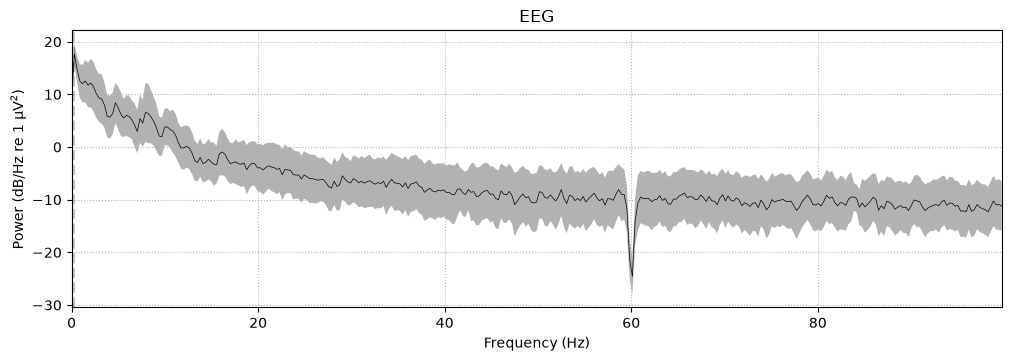

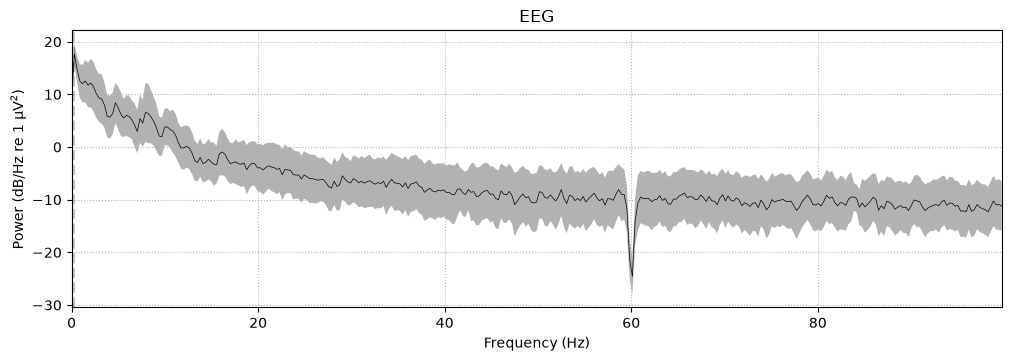

In [16]:
import mne

sample_data_folder = mne.datasets.sample.data_path()
raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(raw_file)
raw.crop(tmax=60).load_data()
clean = raw.copy().notch_filter(60)
clean.compute_psd(fmax=100, picks="eeg").plot(average=True)

In [1]:
raw.plot(picks="eeg", duration=10, n_channels=20)

NameError: name 'raw' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fs = 250
t = np.arange(0, 30, 1/fs)
rng = np.random.default_rng(0)
noise = rng.normal(0, 1, t.size)

awake  = 3 * np.sin(2 * np.pi * 10 * t) + noise + np.sin(2 * np.pi * 60 * t)
asleep = 6 * np.sin(2 * np.pi * 2 * t)  + noise + np.sin(2 * np.pi * 60 * t)

plt.plot(t[:500], awake[:500], label="awake")
plt.plot(t[:500], asleep[:500], label="asleep")
plt.xlabel("Time (s)")
plt.legend()
plt.show()